### According to qc report: Correlations are not as high as expected

In [ ]:
- check the number of oligos
- check the dna and rna correlation
- check the library complexity


In [2]:
# Loading the MPRAlib library
from mpralib.mpradata import MPRABarcodeData
# Loading other libraries
import pandas as pd
import numpy as np

# NGN2 resequencing data:
barcode_table_path = "/data/cephfs-2/unmirrored/groups/kircher/IGVF_data_submssion_TM/80K/mprasnakeflow/results/experiments/defaultNGN2/reporter_experiment.barcode.NGN2.defaultAssignment.default.all.tsv.gz"
# wtc11 resequencing data:
barcode_table_path = "/data/cephfs-2/unmirrored/groups/kircher/IGVF_data_submssion_TM/80K/mprasnakeflow/results/experiments/defaultWTC11Resequencing/reporter_experiment.barcode.WTC11.defaultAssignmentBBMap.default.all.tsv.gz"



# Load the data
mpra_barcode_data = MPRABarcodeData.from_file(barcode_table_path)

# Getting counts, no filtering/sampling done, so raw counts
print("DNA counts")
display(pd.DataFrame(mpra_barcode_data.dna_counts[:,0:5], index=mpra_barcode_data.obs_names, columns=mpra_barcode_data.var_names[0:5]))
print("RNA counts")
display(pd.DataFrame(mpra_barcode_data.rna_counts[:,0:5], index=mpra_barcode_data.obs_names, columns=mpra_barcode_data.var_names[0:5]))

DNA counts


barcode,TGTATGCCTTATCCG,GCGTTACAGTCCTTC,CAATGGAAGCCAGAC,AGCGGAATTTGTCTA,CTCGTTCACCCTTAG
1,0,4,8,6,0
2,5,0,0,0,0
3,5,0,11,0,8


RNA counts


barcode,TGTATGCCTTATCCG,GCGTTACAGTCCTTC,CAATGGAAGCCAGAC,AGCGGAATTTGTCTA,CTCGTTCACCCTTAG
1,0,19,29,5,0
2,19,0,0,0,0
3,8,0,27,0,8


In [3]:
# helpful functions
def mean_correlation_of_mpra_oligo_matrix(matrix):
    """Get only the correlation values of the upper triangle of the matrix to compute the mean correlation"""
    return np.mean(matrix[np.triu_indices_from(matrix, k=1)]).round(3)


### Correlation
- We can correlate replicates based on DNA/RNA counts or activity. We are able to do this on a barcode level. But usually this generates very very low correlations:


In [2]:
from mpralib.mpradata import Modality
print("Pairwise Pearson correlation activity")
print(pd.DataFrame(mpra_barcode_data.correlation(), index=mpra_barcode_data.obs_names, columns=mpra_barcode_data.obs_names).round(3))
print("Pairwise Pearson correlation normalized DNA")
print(pd.DataFrame(mpra_barcode_data.correlation(count_type=Modality.DNA_NORMALIZED), index=mpra_barcode_data.obs_names, columns=mpra_barcode_data.obs_names).round(3))
print("Pairwise Pearson correlation normalized RNA")
print(pd.DataFrame(mpra_barcode_data.correlation(count_type=Modality.RNA_NORMALIZED), index=mpra_barcode_data.obs_names, columns=mpra_barcode_data.obs_names).round(3))


Pairwise Pearson correlation activity
       1      2      3
1  1.000  0.172  0.168
2  0.172  1.000  0.176
3  0.168  0.176  1.000
Pairwise Pearson correlation normalized DNA
       1     2      3
1  1.000  0.20  0.211
2  0.200  1.00  0.210
3  0.211  0.21  1.000
Pairwise Pearson correlation normalized RNA
       1      2      3
1  1.000  0.576  0.590
2  0.576  1.000  0.593
3  0.590  0.593  1.000


- Unfiltered WTC11 data: 

Pairwise Pearson correlation activity
       1      2      3
1  1.000  0.172  0.168
2  0.172  1.000  0.176
3  0.168  0.176  1.000
Pairwise Pearson correlation normalized DNA
       1     2      3
1  1.000  0.20  0.211
2  0.200  1.00  0.210
3  0.211  0.21  1.000
Pairwise Pearson correlation normalized RNA
       1      2      3
1  1.000  0.576  0.590
2  0.576  1.000  0.593
3  0.590  0.593  1.000

- Unfiltered NGN2 data: 

Pairwise Pearson correlation activity
       1      2      3
1  1.000  0.267  0.258
2  0.267  1.000  0.247
3  0.258  0.247  1.000
Pairwise Pearson correlation normalized DNA
       1      2      3
1  1.000  0.566  0.584
2  0.566  1.000  0.580
3  0.584  0.580  1.000
Pairwise Pearson correlation normalized RNA
       1      2      3
1  1.000  0.816  0.831
2  0.816  1.000  0.814
3  0.831  0.814  1.000


### Aggregate the data per oligo not per barcode

In [ ]:
mpra_oligo_data = mpra_barcode_data.oligo_data

print("Pairwise Pearson correlation")
print(pd.DataFrame(mpra_oligo_data.correlation(), index=mpra_oligo_data.obs_names, columns=mpra_oligo_data.obs_names).round(3))
print("Parwise Spearman correlation")
print(pd.DataFrame(mpra_oligo_data.correlation(method="spearman"), index=mpra_oligo_data.obs_names, columns=mpra_oligo_data.obs_names).round(3))


# Setting a different barcode threshold 1, 10, 50 and getting the average across replicates
for threshold in [1, 15, 50, 75, 100, 200]:
    mpra_oligo_data.barcode_threshold = threshold
    print(f"Mean Pearson correlation activity, BC threshold {mpra_oligo_data.barcode_threshold}: {mpra_oligo_data.correlation().flatten()[[1,2,5]].mean().round(3)}")

    print(f"Mean Pearson correlation RNA counts (normalized), BC threshold {mpra_oligo_data.barcode_threshold}: {mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation(count_type=Modality.RNA_NORMALIZED))}")

    print(f"Mean Pearson correlation DNA counts (normalized), BC threshold {mpra_oligo_data.barcode_threshold}: {mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation(count_type=Modality.DNA_NORMALIZED))}")

    print("")


Pairwise Pearson correlation
       1      2      3
1  1.000  0.260  0.217
2  0.260  1.000  0.206
3  0.217  0.206  1.000
Parwise Spearman correlation
       1      2      3
1  1.000  0.652  0.652
2  0.652  1.000  0.661
3  0.652  0.661  1.000
Mean Pearson correlation activity, BC threshold 1: 0.654
Mean Pearson correlation RNA counts (normalized), BC threshold 1: 0.635
Mean Pearson correlation DNA counts (normalized), BC threshold 1: 0.453

Mean Pearson correlation activity, BC threshold 15: 0.786
Mean Pearson correlation RNA counts (normalized), BC threshold 15: 0.649
Mean Pearson correlation DNA counts (normalized), BC threshold 15: 0.5

Mean Pearson correlation activity, BC threshold 50: 0.826
Mean Pearson correlation RNA counts (normalized), BC threshold 50: 0.655
Mean Pearson correlation DNA counts (normalized), BC threshold 50: 0.531

Mean Pearson correlation activity, BC threshold 75: 0.833
Mean Pearson correlation RNA counts (normalized), BC threshold 75: 0.658
Mean Pearson corr

In [4]:
mpra_oligo_data = mpra_barcode_data.oligo_data


In [ ]:
from mpralib.mpradata import Modality

mpra_barcode_data
print("Pairwise Pearson correlation activity")
print(pd.DataFrame(mpra_barcode_data.correlation(), index=mpra_barcode_data.obs_names, columns=mpra_barcode_data.obs_names).round(3))
print("Pairwise Pearson correlation normalized DNA")
print(pd.DataFrame(mpra_barcode_data.correlation(count_type=Modality.DNA_NORMALIZED), index=mpra_barcode_data.obs_names, columns=mpra_barcode_data.obs_names).round(3))
print("Pairwise Pearson correlation normalized RNA")
print(pd.DataFrame(mpra_barcode_data.correlation(count_type=Modality.RNA_NORMALIZED), index=mpra_barcode_data.obs_names, columns=mpra_barcode_data.obs_names).round(3))


### We can also plot the correlation. Let's do it for barcode_threshold 50:

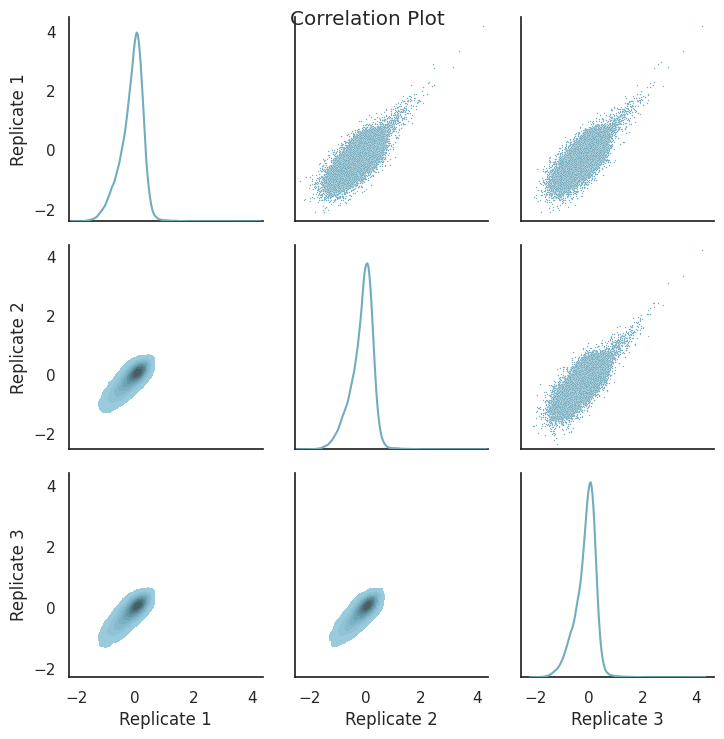

In [6]:
from mpralib.utils.plot import correlation
from mpralib.mpradata import Modality

mpra_oligo_data.barcode_threshold = 15
correlation(mpra_oligo_data, Modality.ACTIVITY)

/home/kisa/miniforge3/envs/mpralib/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kisa/miniforge3/envs/mpralib/lib/python3.9/site-packages/mpralib/utils/plot.py:63: RuntimeWarning: divide by zero encountered in log10
  df = pd.DataFrame({"DNA [log10]": np.log10(median_dna), "RNA [log10]": np.log10(median_rna)})


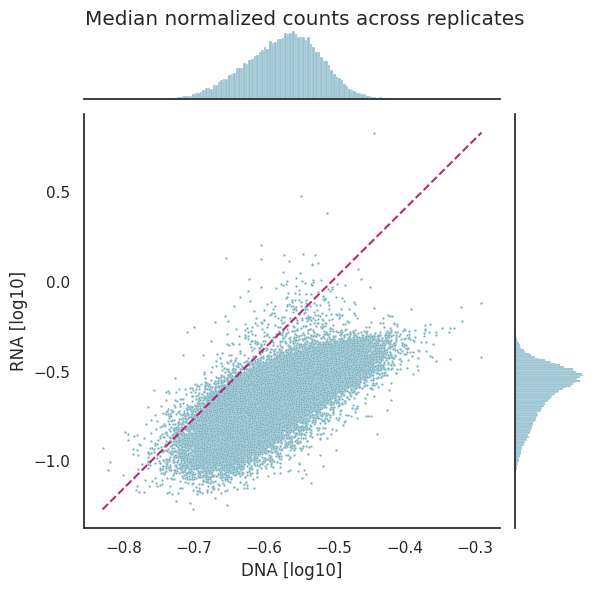

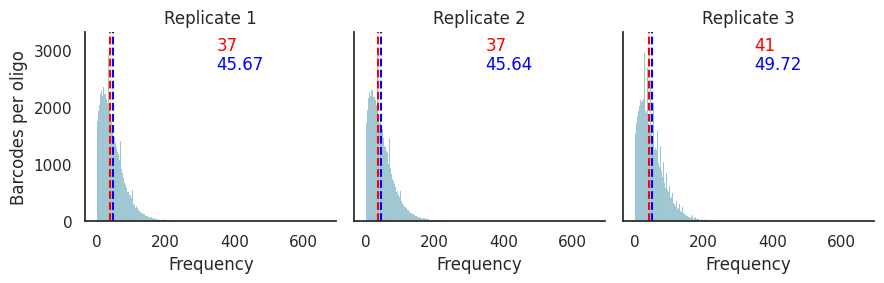

In [7]:
from mpralib.utils.plot import dna_vs_rna,barcodes_per_oligo

dna_vs_rna(mpra_oligo_data)

barcodes_per_oligo(mpra_oligo_data)

In [8]:
print("Pairwise Pearson correlation")
print(pd.DataFrame(mpra_oligo_data.correlation(), index=mpra_oligo_data.obs_names, columns=mpra_oligo_data.obs_names).round(3))
print("Parwise Spearman correlation")
print(pd.DataFrame(mpra_oligo_data.correlation(method="spearman"), index=mpra_oligo_data.obs_names, columns=mpra_oligo_data.obs_names).round(3))

Pairwise Pearson correlation
       1      2      3
1  1.000  0.782  0.783
2  0.782  1.000  0.793
3  0.783  0.793  1.000
Parwise Spearman correlation
       1      2      3
1  1.000  0.725  0.724
2  0.725  1.000  0.733
3  0.724  0.733  1.000


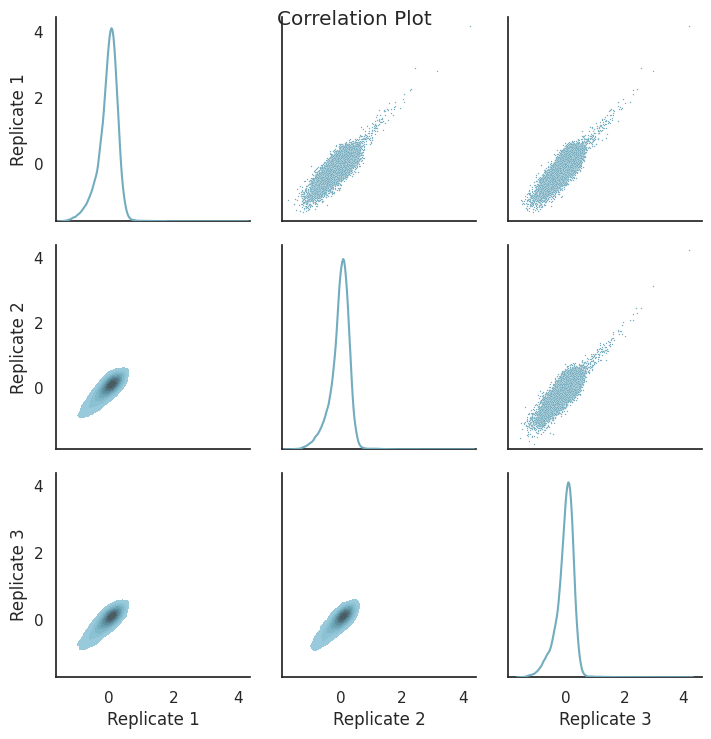

In [4]:
from mpralib.utils.plot import correlation
mpra_oligo_data.barcode_threshold = 50
correlation(mpra_oligo_data, Modality.ACTIVITY)

/home/kisa/miniforge3/envs/mpralib/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kisa/miniforge3/envs/mpralib/lib/python3.9/site-packages/mpralib/utils/plot.py:63: RuntimeWarning: divide by zero encountered in log10
  df = pd.DataFrame({"DNA [log10]": np.log10(median_dna), "RNA [log10]": np.log10(median_rna)})


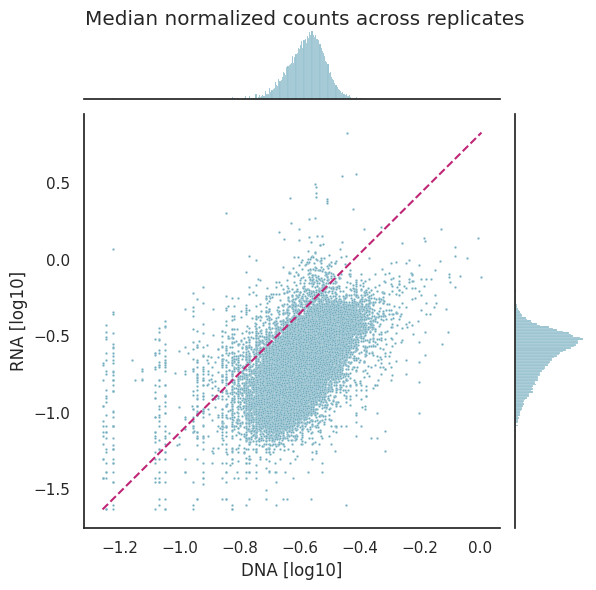

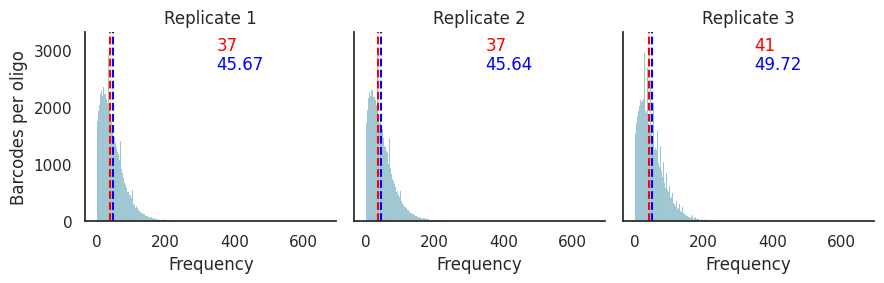

In [5]:
from mpralib.utils.plot import dna_vs_rna,barcodes_per_oligo
mpra_oligo_data.barcode_threshold = 0
dna_vs_rna(mpra_oligo_data)

barcodes_per_oligo(mpra_oligo_data)

/home/kisa/miniforge3/envs/mpralib/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kisa/miniforge3/envs/mpralib/lib/python3.9/site-packages/mpralib/utils/plot.py:63: RuntimeWarning: divide by zero encountered in log10
  df = pd.DataFrame({"DNA [log10]": np.log10(median_dna), "RNA [log10]": np.log10(median_rna)})


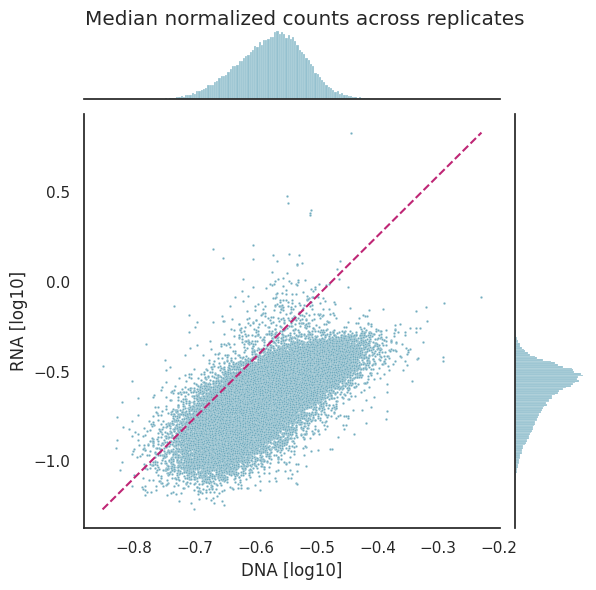

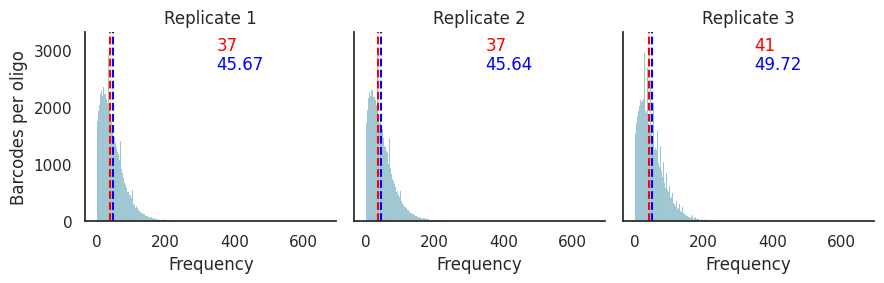

In [6]:
from mpralib.utils.plot import dna_vs_rna,barcodes_per_oligo
mpra_oligo_data.barcode_threshold = 10
dna_vs_rna(mpra_oligo_data)
barcodes_per_oligo(mpra_oligo_data)


/home/kisa/miniforge3/envs/mpralib/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kisa/miniforge3/envs/mpralib/lib/python3.9/site-packages/mpralib/utils/plot.py:63: RuntimeWarning: divide by zero encountered in log10
  df = pd.DataFrame({"DNA [log10]": np.log10(median_dna), "RNA [log10]": np.log10(median_rna)})


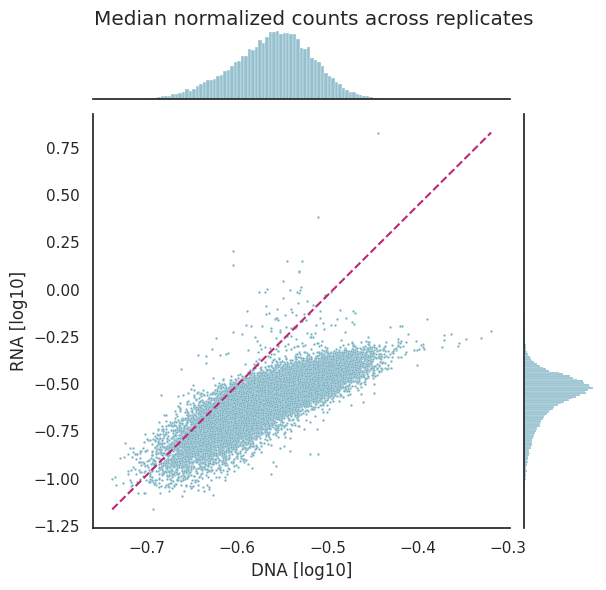

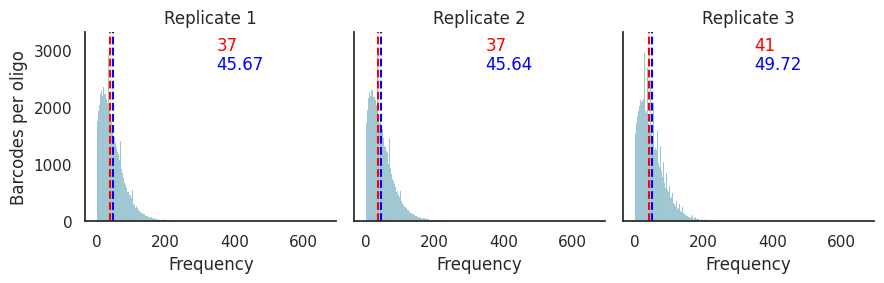

In [7]:
from mpralib.utils.plot import dna_vs_rna,barcodes_per_oligo
mpra_oligo_data.barcode_threshold = 50
dna_vs_rna(mpra_oligo_data)

barcodes_per_oligo(mpra_oligo_data)

### Check barcode threshold influencing the number of oligos remaining in the analysis

In [1]:
mpra_oligo_data.barcode_threshold = 15

mpra_oligo_data.correlation()
mpra_oligo_data.correlation(method="spearman")

NameError: name 'mpra_oligo_data' is not defined

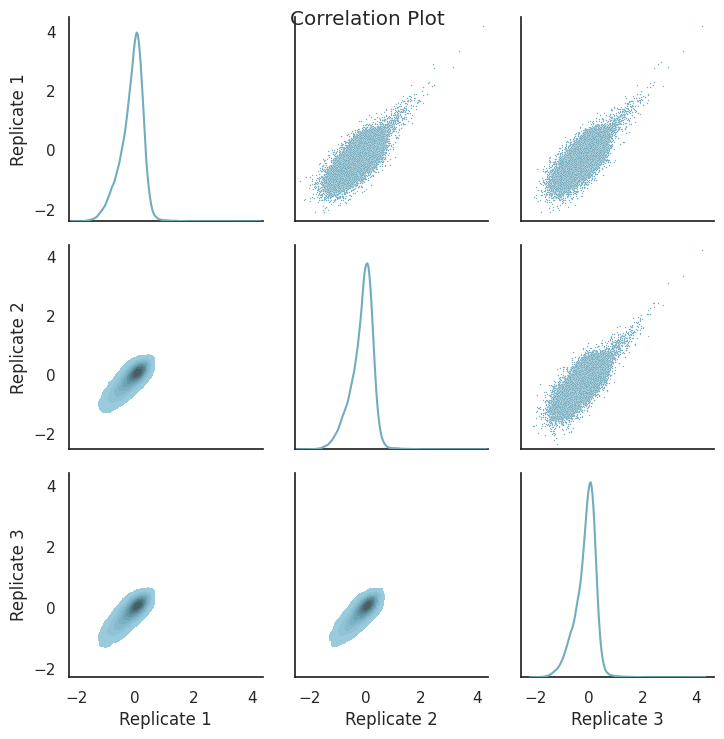

In [9]:
correlation(mpra_oligo_data, Modality.ACTIVITY)

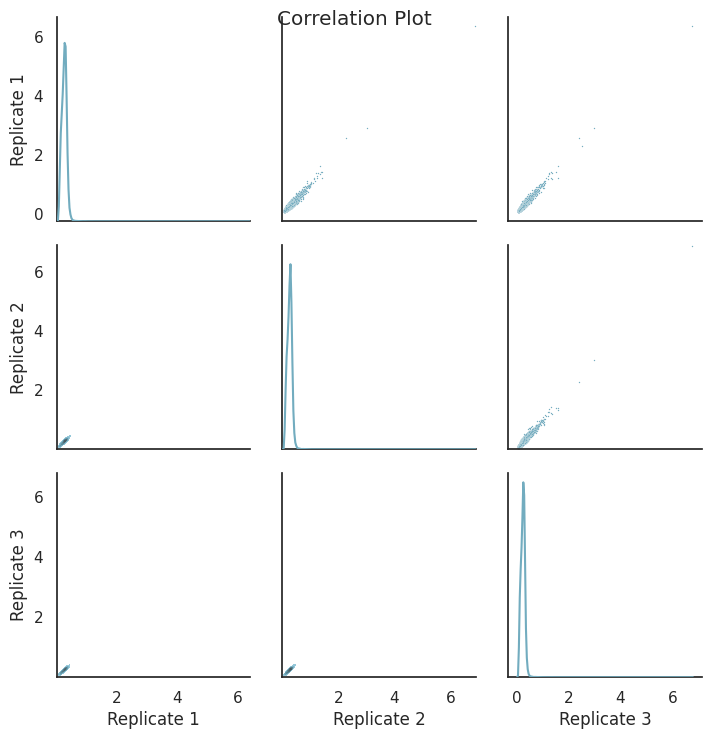

In [10]:
correlation(mpra_oligo_data, Modality.RNA_NORMALIZED)


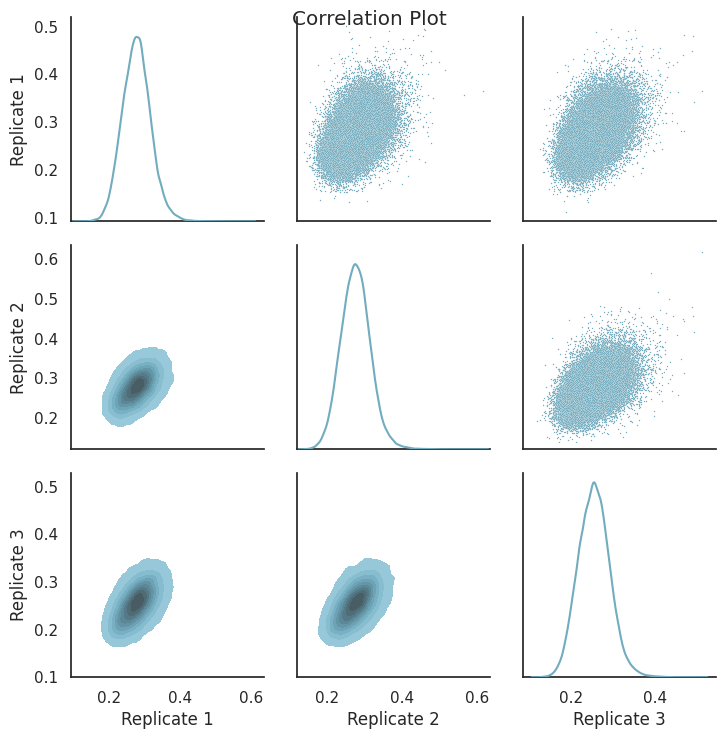

In [11]:
correlation(mpra_oligo_data, Modality.DNA_NORMALIZED)

In [12]:
import numpy as np

def mean_correlation_of_mpra_oligo_matrix(matrix):
    """Get only the correlation values of the upper triangle of the matrix to compute the mean correlation"""
    return np.mean(matrix[np.triu_indices_from(matrix, k=1)]).round(3)


# using no barcode filter
mpra_oligo_data.barcode_threshold = 0
print(f"Mean Pearson correlation, BC threshold {mpra_oligo_data.barcode_threshold}")
print(mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation()))
print(f"Mean Spearman correlation, BC threshold {mpra_oligo_data.barcode_threshold}")
print(mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation(method="spearman")))
print(f"Number of oligs")
print(np.sum(mpra_oligo_data.barcode_counts >= mpra_oligo_data.barcode_threshold,axis=1))


# Resetting the barcode filter
mpra_barcode_data.barcode_threshold = 10
mpra_barcode_data.barcode_filter = None
mpra_oligo_data = mpra_barcode_data.oligo_data
print(f"Mean Pearson correlation, BC threshold {mpra_oligo_data.barcode_threshold}")
print(mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation()))
print(f"Mean Spearman correlation, BC threshold {mpra_oligo_data.barcode_threshold}")
print(mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation(method="spearman")))
print(f"Number of oligs")
print(np.sum(mpra_oligo_data.barcode_counts >= mpra_oligo_data.barcode_threshold,axis=1))


# Resetting the barcode filter
mpra_barcode_data.barcode_threshold = 15
mpra_barcode_data.barcode_filter = None
mpra_oligo_data = mpra_barcode_data.oligo_data
print(f"Mean Pearson correlation, BC threshold {mpra_oligo_data.barcode_threshold}")
print(mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation()))
print(f"Mean Spearman correlation, BC threshold {mpra_oligo_data.barcode_threshold}")
print(mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation(method="spearman")))
print(f"Number of oligs")
print(np.sum(mpra_oligo_data.barcode_counts >= mpra_oligo_data.barcode_threshold,axis=1))


# Resetting the barcode filter
mpra_barcode_data.barcode_threshold = 45
mpra_barcode_data.barcode_filter = None
mpra_oligo_data = mpra_barcode_data.oligo_data
print(f"Mean Pearson correlation, BC threshold {mpra_oligo_data.barcode_threshold}")
print(mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation()))
print(f"Mean Spearman correlation, BC threshold {mpra_oligo_data.barcode_threshold}")
print(mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation(method="spearman")))
print(f"Number of oligs")
print(np.sum(mpra_oligo_data.barcode_counts >= mpra_oligo_data.barcode_threshold,axis=1))


# Resetting the barcode filter
mpra_barcode_data.barcode_threshold = 75
mpra_barcode_data.barcode_filter = None
mpra_oligo_data = mpra_barcode_data.oligo_data
print(f"Mean Pearson correlation, BC threshold {mpra_oligo_data.barcode_threshold}")
print(mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation()))
print(f"Mean Spearman correlation, BC threshold {mpra_oligo_data.barcode_threshold}")
print(mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation(method="spearman")))
print(f"Number of oligs")
print(np.sum(mpra_oligo_data.barcode_counts >= mpra_oligo_data.barcode_threshold,axis=1))

Mean Pearson correlation, BC threshold 0
0.228
Mean Spearman correlation, BC threshold 0
0.655
Number of oligs
[77876 77876 77876]
Mean Pearson correlation, BC threshold 10
0.765
Mean Spearman correlation, BC threshold 10
0.714
Number of oligs
[68960 69087 69927]
Mean Pearson correlation, BC threshold 15
0.786
Mean Spearman correlation, BC threshold 15
0.727
Number of oligs
[63426 63506 65009]
Mean Pearson correlation, BC threshold 45
0.826
Mean Spearman correlation, BC threshold 45
0.738
Number of oligs
[32408 32496 35774]
Mean Pearson correlation, BC threshold 75
0.833
Mean Spearman correlation, BC threshold 75
0.728
Number of oligs
[13876 13831 16600]


In [13]:
from mpralib.mpradata import BarcodeFilter

# Resetting the barcode filter
mpra_barcode_data.barcode_threshold = 200
mpra_barcode_data.barcode_filter = None
mpra_oligo_data = mpra_barcode_data.oligo_data
print(f"Mean Pearson correlation before BC filter, BC threshold {mpra_oligo_data.barcode_threshold}")
print(mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation()))
print(f"Mean Spearman correlation before BC filter, BC threshold {mpra_oligo_data.barcode_threshold}")
print(mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation(method="spearman")))
print(f"Number of oligs")
print(np.sum(mpra_oligo_data.barcode_counts >= mpra_oligo_data.barcode_threshold,axis=1))

# Apply filter
mpra_barcode_data.apply_barcode_filter(BarcodeFilter.RNA_ZSCORE, {"times_zscore": 3})

mpra_oligo_data = mpra_barcode_data.oligo_data
print(f"Mean Pearson correlation before BC filter, BC threshold {mpra_oligo_data.barcode_threshold}")
print(mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation()))
print(f"Mean Spearman correlation before BC filter, BC threshold {mpra_oligo_data.barcode_threshold}")
print(mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation(method="spearman")))
print(f"Number of oligs")
print(np.sum(mpra_oligo_data.barcode_counts >= mpra_oligo_data.barcode_threshold,axis=1))


Mean Pearson correlation before BC filter, BC threshold 200
0.908
Mean Spearman correlation before BC filter, BC threshold 200
0.847
Number of oligs
[315 313 464]
Mean Pearson correlation before BC filter, BC threshold 200
0.909
Mean Spearman correlation before BC filter, BC threshold 200
0.838
Number of oligs
[289 291 426]
